# Кластеризация изображений

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
import umap
import networkx as nx
from sknetwork.clustering import PropagationClustering, get_modularity
import seaborn as sns
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as SSIM
from skimage import img_as_float
import imagehash
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, completeness_score, homogeneity_score

**Метрики кластеризации "с учителем" - adjusted_rand_score, adjusted_mutual_info_score, completeness_score, homogeneity_score**

### Проекция эмбеддингов с уменьшением размерности

In [99]:
reducer = umap.UMAP(n_neighbors=6, min_dist=0.01)

In [7]:
emb_df = pd.read_parquet('embeddings&markup/image_embeddings.pq')

In [101]:
emb_df.head(3)

,image_path,embedding,embedding_clf,embedding_cnn,color_vector
0,/cv-sandbox/project/data/IMG_20221201_131637.jpg,"[-2.8007195, 0.1795005, 2.0634825, 0.31013796,...","[-1.198553, -0.61378217, -0.49053022, -1.18711...","[0.30277967, 0.7905779, 0.294772, 0.8011666, 0...","[0.011503007322175731, 0.00515821129707113, 0...."
1,/cv-sandbox/project/data/IMG_20220422_185636.jpg,"[-0.39972767, 0.23981501, 1.5460123, -1.038316...","[-3.2148683, -1.8561819, -3.4543087, -2.958324...","[0.024153264, 0.14707933, 0.0070938347, 0.0894...","[0.021754053347280335, 0.0003432269874476987, ..."
2,/cv-sandbox/project/data/P7081020.JPG,"[0.8322267, 0.17672215, -0.3619432, 0.58000106...","[-1.4701422, 0.23119043, -1.671558, 1.1484444,...","[0.23040602, 0.38108802, 0.16922201, 0.5142818...","[0.05199544270833333, 0.007216796875, 0.004378..."


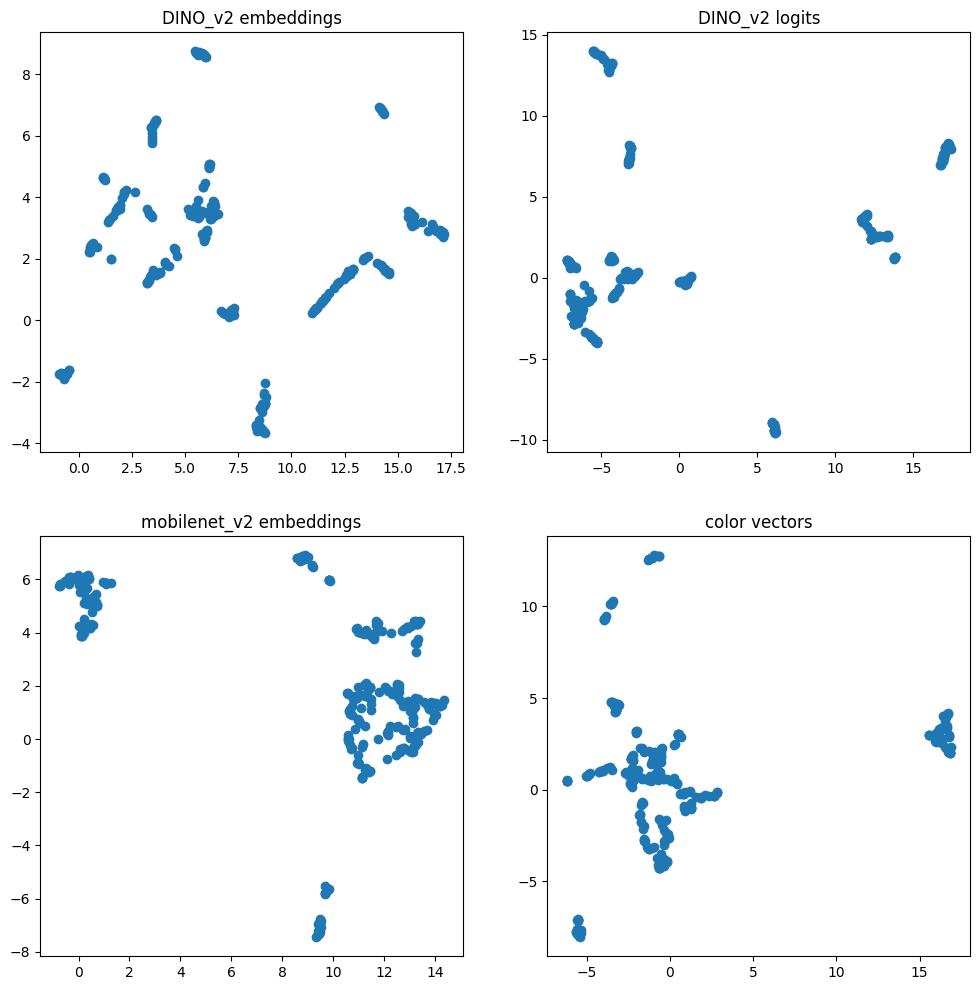

In [103]:
fig, ax = plt.subplots(figsize=(12, 12), nrows=2, ncols=2)
plt.subplot(2, 2, 1)
plt.title('DINO_v2 embeddings')
emb_transformed = reducer.fit_transform(np.vstack(emb_df['embedding'].values))
plt.scatter(emb_transformed[:, 0], emb_transformed[:, 1])
plt.subplot(2, 2, 2)
plt.title('DINO_v2 logits')
emb_clf_transformed = reducer.fit_transform(np.vstack(emb_df['embedding_clf'].values))
plt.scatter(emb_clf_transformed[:, 0], emb_clf_transformed[:, 1])
plt.subplot(2, 2, 3)
plt.title('mobilenet_v2 embeddings')
emb_cnn_transformed = reducer.fit_transform(np.vstack(emb_df['embedding_cnn'].values))
plt.scatter(emb_cnn_transformed[:, 0], emb_cnn_transformed[:, 1])
plt.subplot(2, 2, 4)
plt.title('color vectors')
emb_color_transformed = reducer.fit_transform(np.vstack(emb_df['color_vector'].values))
plt.scatter(emb_color_transformed[:, 0], emb_color_transformed[:, 1])

## Кластеризация плотностным алгоритмом

In [9]:
val_data_orig = pd.read_parquet('embeddings&markup/image_markup.pq')

In [10]:
val_data = val_data_orig.copy()

In [11]:
val_data.loc[val_data['n_samples'] == 1, 'cluster_id'] = -1

In [12]:
val_data.loc[val_data['n_samples'] == 1, 'n_samples'] = (val_data['n_samples'] == 1).sum()

**Найдем оптимальное эпсилон**

In [16]:
# для эмбеддингов трансформера
eps_list = list(range(5, 40, 1))
allmetrics_list1 = []
for eps in eps_list:
    model = DBSCAN(eps=eps, min_samples=2)
    db_clusters = model.fit_predict(np.vstack(emb_df['embedding'].values))
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data['cluster_id'], db_clusters)
    metrics["AMI"] = adjusted_mutual_info_score(val_data['cluster_id'], db_clusters)
    metrics["completeness"] = completeness_score(val_data['cluster_id'], db_clusters)
    metrics["homogeneity"] = homogeneity_score(val_data['cluster_id'], db_clusters)
    allmetrics_list1.append(metrics)

In [17]:
# для логитов трансформера
eps_list = list(range(5, 40, 1))
allmetrics_list2 = []
for eps in eps_list:
    model = DBSCAN(eps=eps, min_samples=2)
    db_clusters = model.fit_predict(np.vstack(emb_df['embedding_clf'].values))
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data['cluster_id'], db_clusters)
    metrics["AMI"] = adjusted_mutual_info_score(val_data['cluster_id'], db_clusters)
    metrics["completeness"] = completeness_score(val_data['cluster_id'], db_clusters)
    metrics["homogeneity"] = homogeneity_score(val_data['cluster_id'], db_clusters)
    allmetrics_list2.append(metrics)

In [30]:
# для эмбеддингов cnn (Mobilenet v2)
eps_list = list(range(5, 40, 1))
allmetrics_list3 = []
for eps in eps_list:
    model = DBSCAN(eps=eps, min_samples=2)
    db_clusters = model.fit_predict(np.vstack(emb_df['embedding_cnn'].values))
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data['cluster_id'], db_clusters)
    metrics["AMI"] = adjusted_mutual_info_score(val_data['cluster_id'], db_clusters)
    metrics["completeness"] = completeness_score(val_data['cluster_id'], db_clusters)
    metrics["homogeneity"] = homogeneity_score(val_data['cluster_id'], db_clusters)
    allmetrics_list3.append(metrics)

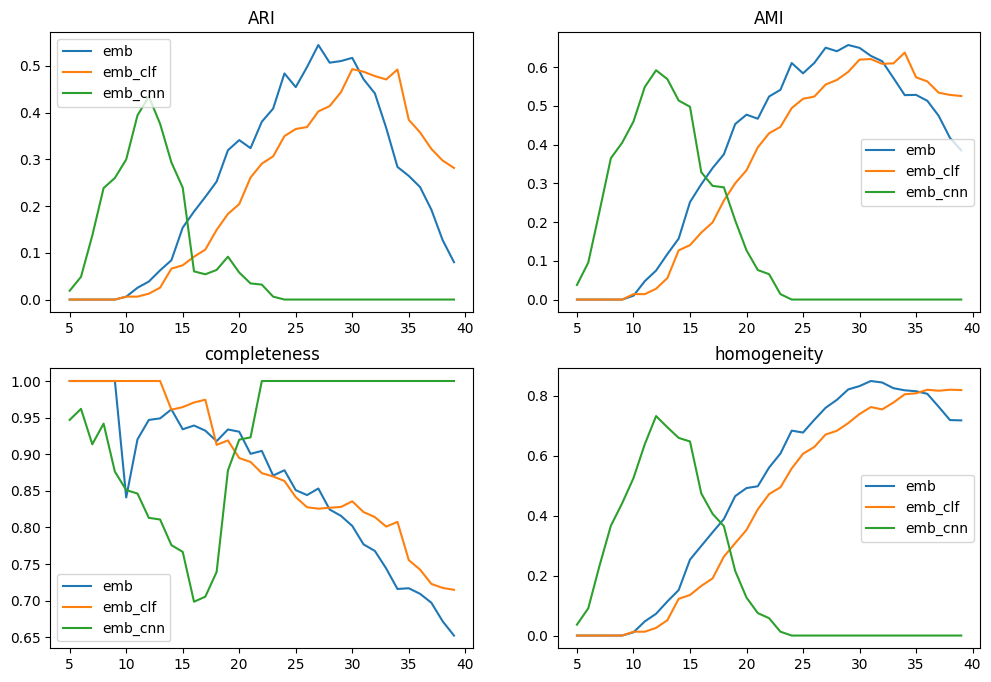

In [21]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
plt.subplot(2, 2, 1)
plt.title('ARI')
plt.plot(eps_list, [m['ARI'] for m in allmetrics_list1], label='emb')
plt.plot(eps_list, [m['ARI'] for m in allmetrics_list2], label='emb_clf')
plt.plot(eps_list, [m['ARI'] for m in allmetrics_list3], label='emb_cnn')
plt.legend()
plt.subplot(2, 2, 2)
plt.title('AMI')
plt.plot(eps_list, [m['AMI'] for m in allmetrics_list1], label='emb')
plt.plot(eps_list, [m['AMI'] for m in allmetrics_list2], label='emb_clf')
plt.plot(eps_list, [m['AMI'] for m in allmetrics_list3], label='emb_cnn')
plt.legend()
plt.subplot(2, 2, 3)
plt.title('completeness')
plt.plot(eps_list, [m['completeness'] for m in allmetrics_list1], label='emb')
plt.plot(eps_list, [m['completeness'] for m in allmetrics_list2], label='emb_clf')
plt.plot(eps_list, [m['completeness'] for m in allmetrics_list3], label='emb_cnn')
plt.legend()
plt.subplot(2, 2, 4)
plt.title('homogeneity')
plt.plot(eps_list, [m['homogeneity'] for m in allmetrics_list1], label='emb')
plt.plot(eps_list, [m['homogeneity'] for m in allmetrics_list2], label='emb_clf')
plt.plot(eps_list, [m['homogeneity'] for m in allmetrics_list3], label='emb_cnn')
plt.legend()

In [90]:
# для цветовых векторов
eps_list1 = np.linspace(0.01, 0.20, 20)
allmetrics_list4 = []
for eps in eps_list1:
    model = DBSCAN(eps=eps, min_samples=2)
    db_clusters = model.fit_predict(np.vstack(emb_df['color_vector'].values))
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data['cluster_id'], db_clusters)
    metrics["AMI"] = adjusted_mutual_info_score(val_data['cluster_id'], db_clusters)
    metrics["completeness"] = completeness_score(val_data['cluster_id'], db_clusters)
    metrics["homogeneity"] = homogeneity_score(val_data['cluster_id'], db_clusters)
    allmetrics_list4.append(metrics)

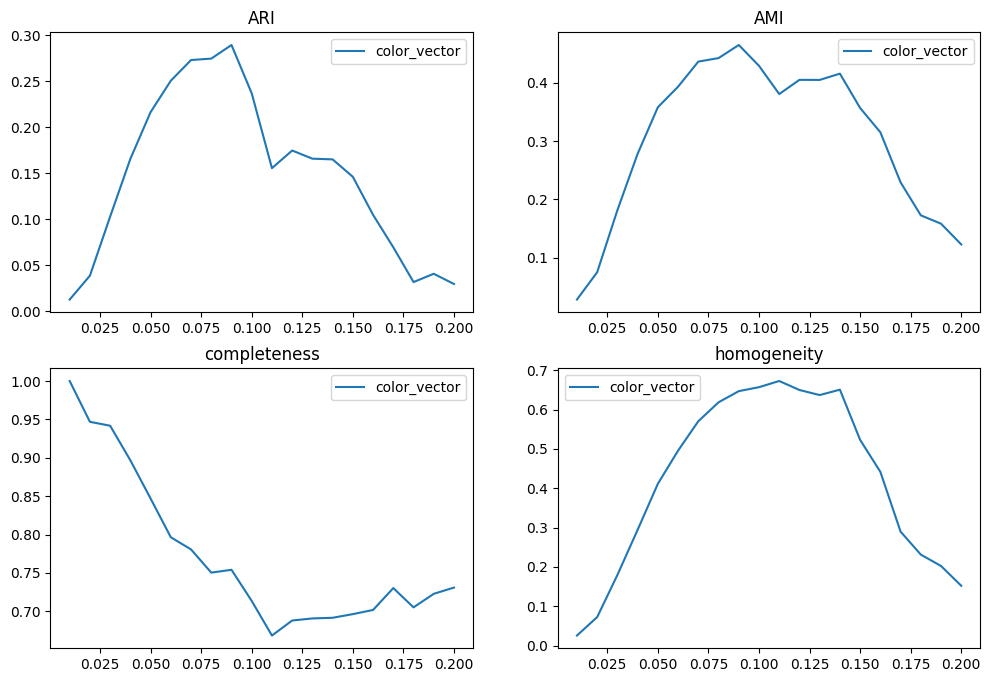

In [32]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
plt.subplot(2, 2, 1)
plt.title('ARI')
plt.plot(eps_list1, [m['ARI'] for m in allmetrics_list4], label='color_vector')
plt.legend()
plt.subplot(2, 2, 2)
plt.title('AMI')
plt.plot(eps_list1, [m['AMI'] for m in allmetrics_list4], label='color_vector')
plt.legend()
plt.subplot(2, 2, 3)
plt.title('completeness')
plt.plot(eps_list1, [m['completeness'] for m in allmetrics_list4], label='color_vector')
plt.legend()
plt.subplot(2, 2, 4)
plt.title('homogeneity')
plt.plot(eps_list1, [m['homogeneity'] for m in allmetrics_list4], label='color_vector')
plt.legend()

**Видим, что:**

+ наивысшие значения метрик достигаются для эмбеддингов трансформера

+ оптимальные эпсилон для эмбеддингов трансформера лежат в диапазоне 27 - 31 (смотря что важнее - чистота (однородность) или полнота), а для эмбеддингов mobilenet - в диапазоне 10-15.

+ для цветовых векторов - около 0.075 - 0.1

In [21]:
eps_list[24]

29

Таким образом, лучшие значения метрик - метрики эмбеддингов трансформера

In [29]:
allmetrics_list1[24]

{'ARI': 0.510342604387437,
 'AMI': 0.6573210055293953,
 'completeness': 0.8158781111959761,
 'homogeneity': 0.8206262741363111}

Метрики эмбеддингов mobilenet

In [38]:
eps_list[7]

12

In [39]:
allmetrics_list3[7]

{'ARI': 0.43441193594554456,
 'AMI': 0.5921274646005409,
 'completeness': 0.8131403887600842,
 'homogeneity': 0.7317489308126306}

Для цветовых векторов

In [36]:
eps_list1[8]

0.09

In [43]:
allmetrics_list4[8]

{'ARI': 0.2891595710517907,
 'AMI': 0.46494848813526474,
 'completeness': 0.7540754957755067,
 'homogeneity': 0.6466441174463717}

### Отнормируем и сконкатенируем эмбеддинги

Не используем логиты классов трансформера; учитываем, что цветовые вектора уже отнормированы

In [71]:
emb_df.head(3)

,image_path,embedding,embedding_clf,embedding_cnn,color_vector
0,/cv-sandbox/project/data/IMG_20221201_131637.jpg,"[-2.8007195, 0.1795005, 2.0634825, 0.31013796,...","[-1.198553, -0.61378217, -0.49053022, -1.18711...","[0.30277967, 0.7905779, 0.294772, 0.8011666, 0...","[0.011503007322175731, 0.00515821129707113, 0...."
1,/cv-sandbox/project/data/IMG_20220422_185636.jpg,"[-0.39972767, 0.23981501, 1.5460123, -1.038316...","[-3.2148683, -1.8561819, -3.4543087, -2.958324...","[0.024153264, 0.14707933, 0.0070938347, 0.0894...","[0.021754053347280335, 0.0003432269874476987, ..."
2,/cv-sandbox/project/data/P7081020.JPG,"[0.8322267, 0.17672215, -0.3619432, 0.58000106...","[-1.4701422, 0.23119043, -1.671558, 1.1484444,...","[0.23040602, 0.38108802, 0.16922201, 0.5142818...","[0.05199544270833333, 0.007216796875, 0.004378..."


In [81]:
emb = np.vstack(emb_df['embedding'].apply(lambda x: x / x.sum()).values)
emb_cnn = np.vstack(emb_df['embedding_cnn'].apply(lambda x: x / x.sum()).values)
emb_color = np.vstack(emb_df['color_vector'].values)

In [82]:
emb.shape

(299, 768)

In [83]:
emb_cnn.shape

(299, 1280)

In [84]:
emb_color.shape

(299, 216)

In [85]:
emb_common = np.hstack([emb, emb_cnn, emb_color])

In [87]:
emb_common.shape

(299, 2264)

In [94]:
%%time
eps_list5 = np.linspace(0.5, 3.5, 41)
allmetrics_list5 = []
for eps in eps_list5:
    model = DBSCAN(eps=eps, min_samples=2)
    db_clusters = model.fit_predict(emb_common)
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data['cluster_id'], db_clusters)
    metrics["AMI"] = adjusted_mutual_info_score(val_data['cluster_id'], db_clusters)
    metrics["completeness"] = completeness_score(val_data['cluster_id'], db_clusters)
    metrics["homogeneity"] = homogeneity_score(val_data['cluster_id'], db_clusters)
    allmetrics_list5.append(metrics)

CPU times: user 5min 29s, sys: 136 ms, total: 5min 29s
Wall time: 10.6 s


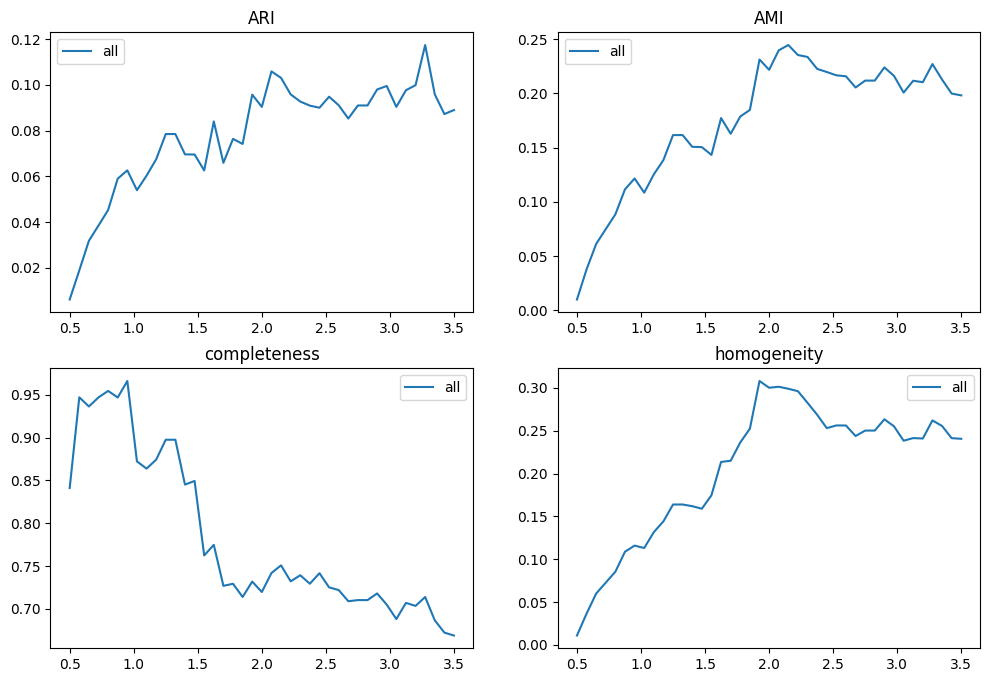

In [95]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
plt.subplot(2, 2, 1)
plt.title('ARI')
plt.plot(eps_list5, [m['ARI'] for m in allmetrics_list5], label='all')
plt.legend()
plt.subplot(2, 2, 2)
plt.title('AMI')
plt.plot(eps_list5, [m['AMI'] for m in allmetrics_list5], label='all')
plt.legend()
plt.subplot(2, 2, 3)
plt.title('completeness')
plt.plot(eps_list5, [m['completeness'] for m in allmetrics_list5], label='all')
plt.legend()
plt.subplot(2, 2, 4)
plt.title('homogeneity')
plt.plot(eps_list5, [m['homogeneity'] for m in allmetrics_list5], label='all')
plt.legend()

Метрики существенно ниже, чем для отдельных эмбеддингов трансформера

---

## Построение и кластеризация графа

Узлы графа - фотографии, связи между ними зависят от расстояния в пространстве эмбеддингов. Строим граф, далее, кластеризуем его.

### Найдем условие формирования связи между фотографиями

In [15]:
val_data_orig.head(3)

,name,datetime,cluster_id,n_samples
0,IMG_20221201_131637.jpg,2022-12-01 13:16:38,1076,1
1,IMG_20220422_185636.jpg,2022-04-22 18:56:38,7,2
2,P7081020.JPG,2023-07-08 19:00:35,61,2


**Разобьем выборку на train и test**

In [ ]:
# val_data_transformed = val_data_orig.groupby(['cluster_id', 'n_samples']).agg({'name': list}).reset_index()

Разбивать будем по целым кластерам

In [157]:
# val_data_transf_train, val_data_transf_test = train_test_split(val_data_transformed, test_size=135)

Проверим, что в train попало хотя бы около 1/3 фотографий

In [47]:
val_data_transf_train['name'].nunique()

98

In [49]:
val_data_transf_test['name'].nunique()

201

In [17]:
# загрузим сохраненное разбиение
val_data_transf_train = pd.read_parquet('embeddings&markup/image_markup_train.pq')
val_data_transf_test = pd.read_parquet('embeddings&markup/image_markup_test.pq')

**Посмотрим на train распределение попарных расстояний для фото внутри и снаружи размеченных групп**

In [61]:
emb_df.head(3)

,image_path,embedding,embedding_clf,embedding_cnn,name
0,/cv-sandbox/project/data/IMG_20221201_131637.jpg,"[-2.8007195, 0.1795005, 2.0634825, 0.31013796,...","[-1.198553, -0.61378217, -0.49053022, -1.18711...","[0.30277967, 0.7905779, 0.294772, 0.8011666, 0...",IMG_20221201_131637.jpg
1,/cv-sandbox/project/data/IMG_20220422_185636.jpg,"[-0.39972767, 0.23981501, 1.5460123, -1.038316...","[-3.2148683, -1.8561819, -3.4543087, -2.958324...","[0.024153264, 0.14707933, 0.0070938347, 0.0894...",IMG_20220422_185636.jpg
2,/cv-sandbox/project/data/P7081020.JPG,"[0.8322267, 0.17672215, -0.3619432, 0.58000106...","[-1.4701422, 0.23119043, -1.671558, 1.1484444,...","[0.23040602, 0.38108802, 0.16922201, 0.5142818...",P7081020.JPG


In [51]:
# emb_df['name'] = emb_df['image_path'].apply(lambda x: x.split('/')[-1])

In [18]:
def add_emb(val_data, emb):
    val_data = val_data.explode('image')
    val_data = val_data.merge(emb, on='name', how='left')
    return val_data

In [19]:
def get_pairs(val_data, id_col, emb_col):
    return list(zip(val_data[id_col].values, val_data[emb_col].values))

In [20]:
val_data_transf_train.head()

,cluster_id,n_samples,name,image_path
0,1111,1,P8020034.JPG,/cv-sandbox/project/data/P8020034.JPG
1,1038,1,IMG_20220626_112428.jpg,/cv-sandbox/project/data/IMG_20220626_112428.jpg
2,1005,1,IMG_20220414_123922.jpg,/cv-sandbox/project/data/IMG_20220414_123922.jpg
3,1026,1,IMG_20220520_095828.jpg,/cv-sandbox/project/data/IMG_20220520_095828.jpg
4,1064,2,IMG_20221025_134510.jpg,/cv-sandbox/project/data/IMG_20221025_134510.jpg


In [21]:
val_data_transf_train.head(3)

,cluster_id,n_samples,name,image_path
0,1111,1,P8020034.JPG,/cv-sandbox/project/data/P8020034.JPG
1,1038,1,IMG_20220626_112428.jpg,/cv-sandbox/project/data/IMG_20220626_112428.jpg
2,1005,1,IMG_20220414_123922.jpg,/cv-sandbox/project/data/IMG_20220414_123922.jpg


In [22]:
val_data_transf_train = val_data_transf_train.merge(emb_df, on='image_path', how='left')  # add_emb(val_data_transf_train, emb_df)

In [51]:
val_data_transf_train.head(3)

,cluster_id,n_samples,name,image_path,embedding,embedding_clf,embedding_cnn,color_vector
0,1111,1,P8020034.JPG,/cv-sandbox/project/data/P8020034.JPG,"[-1.2622095, 0.9774182, -2.1420755, -3.1002448...","[-2.1711867, -0.7914374, -1.4001552, -0.055728...","[0.057085965, 0.13329928, 0.031432975, 1.37469...","[0.450439453125, 2.604166666666667e-05, 0.0, 0..."
1,1038,1,IMG_20220626_112428.jpg,/cv-sandbox/project/data/IMG_20220626_112428.jpg,"[0.64651173, -2.3799286, -0.3568166, -1.893690...","[-0.73010045, -0.82828605, -0.28783903, -3.240...","[0.020973498, 0.47016546, 0.00094291195, 0.602...","[0.06517717050209205, 0.0009937238493723849, 3..."
2,1005,1,IMG_20220414_123922.jpg,/cv-sandbox/project/data/IMG_20220414_123922.jpg,"[-1.839647, 1.1704022, -1.2264094, -2.6847804,...","[1.457366, -0.5532289, 0.042430185, -0.1021980...","[0.30889025, 0.46556827, 0.00835048, 0.4207221...","[6.53765690376569e-06, 0.0001078713389121339, ..."


In [23]:
train_emb_pairs = get_pairs(val_data_transf_train, 'cluster_id', 'embedding')
train_emb_clf_pairs = get_pairs(val_data_transf_train, 'cluster_id', 'embedding_clf')
train_emb_cnn_pairs = get_pairs(val_data_transf_train, 'cluster_id', 'embedding_cnn')
train_emb_color_pairs = get_pairs(val_data_transf_train, 'cluster_id', 'color_vector')

**Строим распределение "внутренних" и "внешних" дистанций**

In [24]:
pair_dist_inside = []
pair_dist_outside = []
for i, p1 in tqdm(enumerate(train_emb_pairs)):
    for p2 in train_emb_pairs[i + 1:]:
        if p1[0] == p2[0]:
            pair_dist_inside.append(np.linalg.norm(p1[1] - p2[1]))
        else:
            pair_dist_outside.append(np.linalg.norm(p1[1] - p2[1]))

98it [00:00, 1483.20it/s]


In [25]:
pair_clf_inside = []
pair_clf_outside = []
for i, p1 in tqdm(enumerate(train_emb_clf_pairs)):
    for p2 in train_emb_clf_pairs[i + 1:]:
        if p1[0] == p2[0]:
            pair_clf_inside.append(np.linalg.norm(p1[1] - p2[1]))
        else:
            pair_clf_outside.append(np.linalg.norm(p1[1] - p2[1]))

98it [00:00, 1488.94it/s]


In [26]:
pair_cnn_inside = []
pair_cnn_outside = []
for i, p1 in tqdm(enumerate(train_emb_cnn_pairs)):
    for p2 in train_emb_cnn_pairs[i + 1:]:
        if p1[0] == p2[0]:
            pair_cnn_inside.append(np.linalg.norm(p1[1] - p2[1]))
        else:
            pair_cnn_outside.append(np.linalg.norm(p1[1] - p2[1]))

98it [00:00, 1476.62it/s]


In [27]:
pair_color_inside = []
pair_color_outside = []
for i, p1 in tqdm(enumerate(train_emb_color_pairs)):
    for p2 in train_emb_color_pairs[i + 1:]:
        if p1[0] == p2[0]:
            pair_color_inside.append(np.linalg.norm(p1[1] - p2[1]))
        else:
            pair_color_outside.append(np.linalg.norm(p1[1] - p2[1]))

98it [00:00, 1585.32it/s]


In [28]:
len(pair_dist_inside)

38

In [29]:
len(pair_dist_outside)

4715

### Посмотрим на отличие распределений попарных расстояний внутри кластеров и между элементами разных кластеров

**(на обуччающей выборке)**

+ "Внутренние расстояния" - попарные расстояния между элементами, находящимися внутри одного и того же кластера
"Внешние расстояния" - попарные расстояния между элементами, находящимися внутри разных кластеров

+ Анализ распределений поможет найти условный порог расстояния, когда два элемента считаются принадлежащими одному кластеру, если расстояние между ними ниже порога.

<AxesSubplot: title={'center': 'Внутренние + внешние расстояния'}, ylabel='Count'>

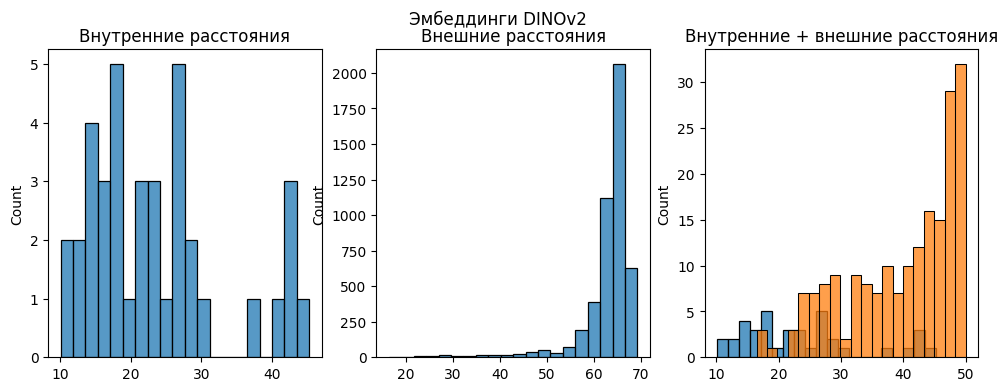

In [105]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.suptitle('Эмбеддинги DINOv2')
plt.subplot(1, 3, 1)
plt.title('Внутренние расстояния')
sns.histplot(pair_dist_inside, bins=20)
plt.subplot(1, 3, 2)
plt.title('Внешние расстояния')
sns.histplot(pair_dist_outside, bins=20)
plt.subplot(1, 3, 3)
plt.title('Внутренние + внешние расстояния')
sns.histplot(pair_dist_inside, bins=20)
sns.histplot([d for d in pair_dist_outside if d < 50], bins=20)

Возможные пороговые расстояния: 25, 30, 33, 36.

<AxesSubplot: title={'center': 'Внутренние + внешние расстояния'}, ylabel='Count'>

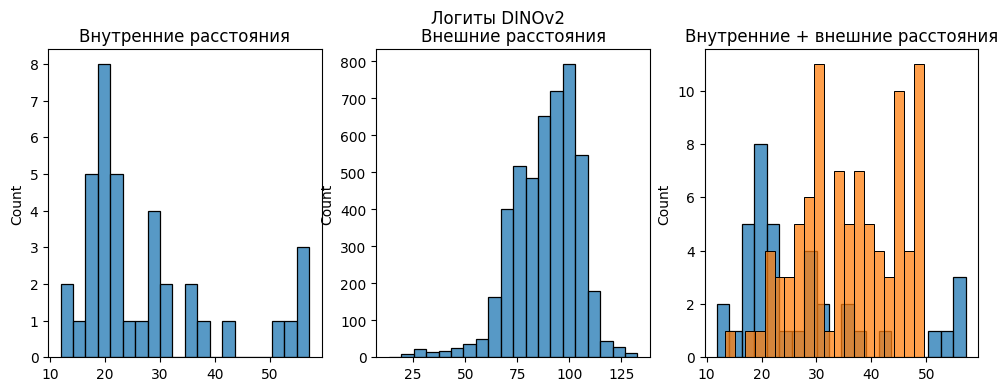

In [106]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.suptitle('Логиты DINOv2')
plt.subplot(1, 3, 1)
plt.title('Внутренние расстояния')
sns.histplot(pair_clf_inside, bins=20)
plt.subplot(1, 3, 2)
plt.title('Внешние расстояния')
sns.histplot(pair_clf_outside, bins=20)
plt.subplot(1, 3, 3)
plt.title('Внутренние + внешние расстояния')
sns.histplot(pair_clf_inside, bins=20)
sns.histplot([d for d in pair_clf_outside if d < 50], bins=20)

<AxesSubplot: title={'center': 'Внутренние + внешние расстояния'}, ylabel='Count'>

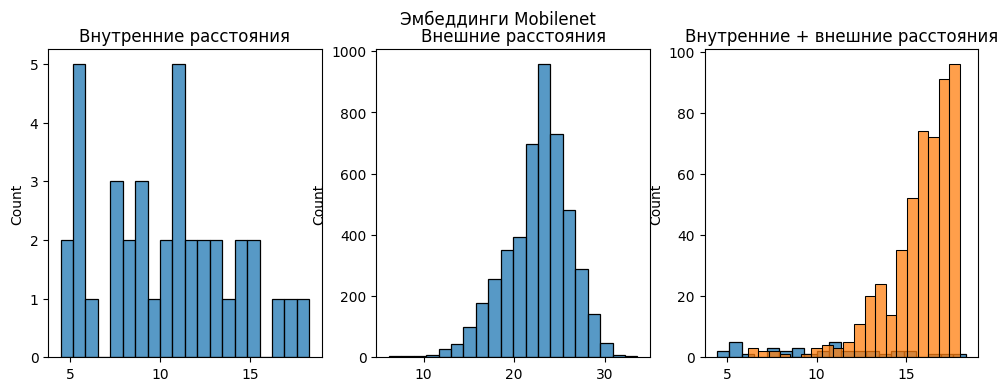

In [107]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.suptitle('Эмбеддинги Mobilenet')
plt.subplot(1, 3, 1)
plt.title('Внутренние расстояния')
sns.histplot(pair_cnn_inside, bins=20)
plt.subplot(1, 3, 2)
plt.title('Внешние расстояния')
sns.histplot(pair_cnn_outside, bins=20)
plt.subplot(1, 3, 3)
plt.title('Внутренние + внешние расстояния')
sns.histplot(pair_cnn_inside, bins=20)
sns.histplot([d for d in pair_cnn_outside if d < 18], bins=20)

Возможные пороговые значения расстояния: 10, 12, 14, 16

<AxesSubplot: title={'center': 'Внутренние + внешние расстояния'}, ylabel='Count'>

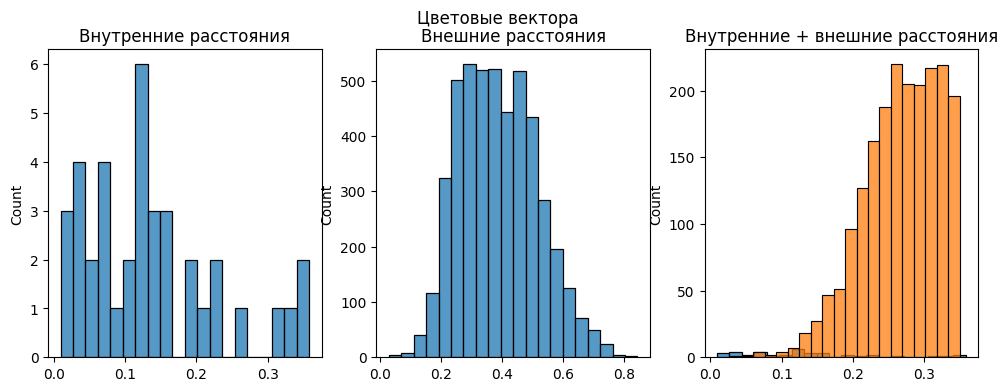

In [108]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.suptitle('Цветовые вектора')
plt.subplot(1, 3, 1)
plt.title('Внутренние расстояния')
sns.histplot(pair_color_inside, bins=20)
plt.subplot(1, 3, 2)
plt.title('Внешние расстояния')
sns.histplot(pair_color_outside, bins=20)
plt.subplot(1, 3, 3)
plt.title('Внутренние + внешние расстояния')
sns.histplot(pair_color_inside, bins=20)
sns.histplot([d for d in pair_color_outside if d < 0.35], bins=20)

Возможные пороговые расстояния: 0.1, 0.25, 0.35

**Судя по распределениям, эмбеддинги трансформера покажут наилучший результат. Стоит попробовать несколько значений порога (разделения фотографий). Например, 25, 30, 33, 36.**

In [31]:
val_data_transf_test = val_data_transf_test.merge(emb_df, on='image_path', how='left')  # val_data_transf_test = add_emb(val_data_transf_test, emb_df)

In [32]:
test_emb_pairs = get_pairs(val_data_transf_test, 'name', 'embedding')

In [33]:
def get_pair_links(samples, thr):
    linked_pairs = []
    for i, (name1, emb1) in tqdm(enumerate(samples)):
        for name2, emb2 in samples[i + 1:]:
            d = np.linalg.norm(emb1 - emb2)
            if d <= thr:
                linked_pairs.append(sorted([name1, name2]))
    return linked_pairs

In [34]:
%%time
linked_pairs_test_22 = get_pair_links(test_emb_pairs, 22)
linked_pairs_test_25 = get_pair_links(test_emb_pairs, 25)
linked_pairs_test_30 = get_pair_links(test_emb_pairs, 30)
linked_pairs_test_33 = get_pair_links(test_emb_pairs, 33)
linked_pairs_test_36 = get_pair_links(test_emb_pairs, 36)

201it [00:00, 921.96it/s]
201it [00:00, 1195.29it/s]
201it [00:00, 1164.56it/s]
201it [00:00, 1181.04it/s]
201it [00:00, 1157.10it/s]

CPU times: user 940 ms, sys: 448 µs, total: 940 ms
Wall time: 922 ms


In [35]:
len(linked_pairs_test_22)

55

In [36]:
len(linked_pairs_test_25)

71

In [37]:
len(linked_pairs_test_30)

124

In [38]:
len(linked_pairs_test_33)

172

In [39]:
len(linked_pairs_test_36)

220

In [40]:
linked_pairs_test_33[:3]

[['IMG_20220626_112127.jpg', 'IMG_20220626_112422.jpg'],
 ['IMG_20220520_095823.jpg', 'IMG_20220520_095833.jpg'],
 ['IMG_20220520_095823.jpg', 'IMG_20220520_095835.jpg']]

In [41]:
def build_graph(linked_pairs):
    G = nx.Graph()
    for p in linked_pairs:
        G.add_edge(p[0], p[1])
    return G

In [42]:
def clusterize_pairs(linked_pairs):
    G = build_graph(linked_pairs)
    adj_matrix = nx.adjacency_matrix(G).todense()
    prop = PropagationClustering(n_iter=5)
    labels = prop.fit_predict(adj_matrix)
    clusters = pd.DataFrame()
    clusters['name'] = list(G.nodes)
    clusters['cluster_id'] = labels
    return clusters

In [43]:
clusters_22 = clusterize_pairs(linked_pairs_test_22)
clusters_25 = clusterize_pairs(linked_pairs_test_25)
clusters_30 = clusterize_pairs(linked_pairs_test_30)
clusters_33 = clusterize_pairs(linked_pairs_test_33)
clusters_36 = clusterize_pairs(linked_pairs_test_36)

In [44]:
clusters_30.head(3)

,name,cluster_id
0,IMG_20220520_095823.jpg,0
1,IMG_20220520_095833.jpg,0
2,IMG_20220520_095835.jpg,0


In [45]:
def calc_metrics(val_data, clusters):
    val_data_merged = val_data[['cluster_id',
                                'n_samples',
                                'name']].merge(clusters.rename({'cluster_id': 'pred_cluster_id'},
                                                               axis=1), on='name', how='left')
    val_data_merged['pred_cluster_id'].fillna(-1, inplace=True)
    val_data_merged.loc[val_data_merged['n_samples'] == 1, 'cluster_id'] = -1
    metrics = {}
    metrics["ARI"] = adjusted_rand_score(val_data_merged['cluster_id'], val_data_merged['pred_cluster_id'])
    metrics["AMI"] = adjusted_mutual_info_score(val_data_merged['cluster_id'], val_data_merged['pred_cluster_id'])
    metrics["completeness"] = completeness_score(val_data_merged['cluster_id'], val_data_merged['pred_cluster_id'])
    metrics["homogeneity"] = homogeneity_score(val_data_merged['cluster_id'], val_data_merged['pred_cluster_id'])
    return metrics

In [48]:
calc_metrics(val_data_transf_test, clusters_22)

{'ARI': 0.3815533949918886,
 'AMI': 0.5452867216993095,
 'completeness': 0.940649661859191,
 'homogeneity': 0.5728125503952957}

In [49]:
calc_metrics(val_data_transf_test, clusters_25)

{'ARI': 0.4683444566311458,
 'AMI': 0.6320976169718784,
 'completeness': 0.910405666203936,
 'homogeneity': 0.695383776002708}

In [50]:
calc_metrics(val_data_transf_test, clusters_30)

{'ARI': 0.5640679426745271,
 'AMI': 0.6900315136046373,
 'completeness': 0.8472661613112236,
 'homogeneity': 0.8388191203634294}

In [51]:
calc_metrics(val_data_transf_test, clusters_33)

{'ARI': 0.43017989613228613,
 'AMI': 0.6166391916583891,
 'completeness': 0.7829491788531334,
 'homogeneity': 0.8518009145355123}

In [52]:
calc_metrics(val_data_transf_test, clusters_36)

{'ARI': 0.30055886554459593,
 'AMI': 0.5688024122396843,
 'completeness': 0.7490461357141689,
 'homogeneity': 0.8555432824680064}

**Выводы:**

+ лучшее значение порога - 30.0

+ лучшие значения метрик при этом - {'ARI': 0.5640679426745271, 'AMI': 0.6900315136046373, 'completeness': 0.8472661613112236, 'homogeneity': 0.8388191203634294}

In [54]:
clusters_30.to_parquet('results/clusters_dino_v2.pq')

In [131]:
thr = 30.0

### Метрики кластеризации графа по другим эмбеддингам

**Mobilenet v2**

In [133]:
test_emb_pairs_cnn = get_pairs(val_data_transf_test, 'name', 'embedding_cnn')

In [125]:
%%time
# пороги 10, 12, 14, 16
linked_pairs_test_cnn_10 = get_pair_links(test_emb_pairs_cnn, 10)
linked_pairs_test_cnn_12 = get_pair_links(test_emb_pairs_cnn, 12)
linked_pairs_test_cnn_14 = get_pair_links(test_emb_pairs_cnn, 14)
linked_pairs_test_cnn_16 = get_pair_links(test_emb_pairs_cnn, 16)

201it [00:00, 880.72it/s]
201it [00:00, 1118.86it/s]
201it [00:00, 1095.87it/s]
201it [00:00, 1082.97it/s]

CPU times: user 789 ms, sys: 12 ms, total: 801 ms
Wall time: 791 ms


In [126]:
clusters_cnn_10 = clusterize_pairs(linked_pairs_test_cnn_10)
clusters_cnn_12 = clusterize_pairs(linked_pairs_test_cnn_12)
clusters_cnn_14 = clusterize_pairs(linked_pairs_test_cnn_14)
clusters_cnn_16 = clusterize_pairs(linked_pairs_test_cnn_16)

In [127]:
calc_metrics(val_data_transf_test, clusters_cnn_10)

{'ARI': 0.3070973338982289,
 'AMI': 0.4835891494625505,
 'completeness': 0.8886114189409405,
 'homogeneity': 0.5449263314805242}

In [128]:
calc_metrics(val_data_transf_test, clusters_cnn_12)

{'ARI': 0.4762991046618526,
 'AMI': 0.6346848636582694,
 'completeness': 0.8340125419636426,
 'homogeneity': 0.789319799987884}

In [129]:
calc_metrics(val_data_transf_test, clusters_cnn_14)

{'ARI': 0.3333658093631578,
 'AMI': 0.5527165976461142,
 'completeness': 0.7780128606493528,
 'homogeneity': 0.7544437905055703}

In [130]:
calc_metrics(val_data_transf_test, clusters_cnn_16)

{'ARI': 0.15423327226579675,
 'AMI': 0.4341640858636456,
 'completeness': 0.7572157135522798,
 'homogeneity': 0.5922942919412414}

Здесь в качестве оптимального порога возьмем 12.0

In [ ]:
cnn_thr = 12.0

**Цветовые вектора**

In [134]:
test_emb_pairs_color = get_pairs(val_data_transf_test, 'name', 'color_vector')

In [140]:
%%time
# пороги 0.08, 0.1, 0.25, 0.35
linked_pairs_test_color_008 = get_pair_links(test_emb_pairs_color, 0.08)
linked_pairs_test_color_01 = get_pair_links(test_emb_pairs_color, 0.1)
linked_pairs_test_color_025 = get_pair_links(test_emb_pairs_color, 0.25)
linked_pairs_test_color_035 = get_pair_links(test_emb_pairs_color, 0.35)

201it [00:00, 1361.96it/s]
201it [00:00, 1947.02it/s]
201it [00:00, 1917.57it/s]
201it [00:00, 1835.62it/s]

CPU times: user 494 ms, sys: 6 µs, total: 494 ms
Wall time: 485 ms


In [141]:
clusters_color_008 = clusterize_pairs(linked_pairs_test_color_008)
clusters_color_01 = clusterize_pairs(linked_pairs_test_color_01)
clusters_color_025 = clusterize_pairs(linked_pairs_test_color_025)
clusters_color_035 = clusterize_pairs(linked_pairs_test_color_035)

In [142]:
calc_metrics(val_data_transf_test, clusters_color_008)

{'ARI': 0.29366009058902487,
 'AMI': 0.4926009876700719,
 'completeness': 0.8094847313103434,
 'homogeneity': 0.6353223040799627}

In [143]:
calc_metrics(val_data_transf_test, clusters_color_01)

{'ARI': 0.2848221719995242,
 'AMI': 0.49551524381052203,
 'completeness': 0.7804479806663536,
 'homogeneity': 0.6779937726937405}

In [144]:
calc_metrics(val_data_transf_test, clusters_color_025)

{'ARI': 0.015672604592573865,
 'AMI': 0.09682155900969018,
 'completeness': 0.623800469691704,
 'homogeneity': 0.1363163593788139}

In [145]:
calc_metrics(val_data_transf_test, clusters_color_035)

{'ARI': 0.0037314731288428955,
 'AMI': 0.005416926009731442,
 'completeness': 0.7799816761968016,
 'homogeneity': 0.007950353331821786}

Здесь в качестве оптимального порога возьмем 0.1

In [146]:
color_thr = 0.1

## Используем все эмбеддинги: вес связи в графе равен количеству связей по разным эмбеддингам

In [ ]:
# all_pairs = linked_pairs_test_30 + linked_pairs_test_cnn_12 + linked_pairs_test_color_01

In [282]:
G = build_graph(linked_pairs_test_30)

In [283]:
for p in linked_pairs_test_cnn_12 + linked_pairs_test_color_01:
    if (p[0], p[1]) in G.edges:
        w = G.edges[(p[0], p[1])].setdefault('weight', 1)
        G.edges[(p[0], p[1])]['weight'] += 1
    else:
        G.add_edge(p[0], p[1], weight=1)

In [285]:
adj_matrix = nx.adjacency_matrix(G).todense()
adj_matrix = np.where(adj_matrix < 0, 0, adj_matrix)
prop = PropagationClustering(n_iter=5)
labels = prop.fit_predict(adj_matrix)
clusters = pd.DataFrame()
clusters['name'] = list(G.nodes)
clusters['cluster_id'] = labels

In [286]:
calc_metrics(val_data_transf_test, clusters)

{'ARI': 0.32707243942055286,
 'AMI': 0.5817931065291856,
 'completeness': 0.7559140779210751,
 'homogeneity': 0.8596956905418704}

"Совместные" метрики оказались хуже метрик на эмбеддингамх трансформера

# Другие методы сравнения изображений

## SSIM

In [300]:
val_data_transf_train.head(10)

,cluster_id,n_samples,name,image_path,embedding,embedding_clf
0,1111,1,P8020034.JPG,/cv-sandbox/project/data/P8020034.JPG,"[-1.2622095, 0.9774182, -2.1420755, -3.1002448...","[-2.1711867, -0.7914374, -1.4001552, -0.055728..."
1,1038,1,IMG_20220626_112428.jpg,/cv-sandbox/project/data/IMG_20220626_112428.jpg,"[0.64651173, -2.3799286, -0.3568166, -1.893690...","[-0.73010045, -0.82828605, -0.28783903, -3.240..."
2,1005,1,IMG_20220414_123922.jpg,/cv-sandbox/project/data/IMG_20220414_123922.jpg,"[-1.839647, 1.1704022, -1.2264094, -2.6847804,...","[1.457366, -0.5532289, 0.042430185, -0.1021980..."
3,1026,1,IMG_20220520_095828.jpg,/cv-sandbox/project/data/IMG_20220520_095828.jpg,"[-2.6815364, 1.8652434, -0.05012386, -0.25534,...","[2.2991781, -1.2498221, -2.4275024, 0.11851107..."
4,1064,2,IMG_20221025_134510.jpg,/cv-sandbox/project/data/IMG_20221025_134510.jpg,"[-1.5174276, 0.02353805, 0.2661705, -0.9630355...","[-0.02090269, -0.23660317, -2.785536, -0.26438..."
5,1064,2,IMG_20221025_134512.jpg,/cv-sandbox/project/data/IMG_20221025_134512.jpg,"[-2.009449, 0.5456189, 0.8870092, -0.55964243,...","[0.17286678, -0.8811291, -2.908575, 0.2906819,..."
6,1057,2,IMG_20220923_220303.jpg,/cv-sandbox/project/data/IMG_20220923_220303.jpg,"[0.5063733, 0.058872283, -1.7417876, 0.0189506...","[-2.5000913, 0.93129325, -2.63137, -2.3998647,..."
7,1057,2,IMG_20220923_220254.jpg,/cv-sandbox/project/data/IMG_20220923_220254.jpg,"[-0.50198966, -0.10457408, -1.6157572, 0.02018...","[-2.7136421, 0.14839838, -2.8008366, -2.340972..."
8,25,2,IMG_20220717_203847.jpg,/cv-sandbox/project/data/IMG_20220717_203847.jpg,"[0.26798075, 2.3280935, -1.9592195, 0.54510325...","[-2.22502, -0.27824184, -0.7106072, -2.7500057..."
9,25,2,IMG_20220717_203844.jpg,/cv-sandbox/project/data/IMG_20220717_203844.jpg,"[-1.0295393, 0.49814498, -1.7714171, 0.9788697...","[-1.6908584, -0.22155489, 0.39998558, -2.20371..."


**Сравним SSIM для похожих и непохожих изображений**

In [329]:
img0 = Image.open('/cv-sandbox/project/data/P8020034.JPG').convert('RGB').resize()

In [311]:
img1 = Image.open('/cv-sandbox/project/data/IMG_20221025_134510.jpg').convert('RGB')

In [317]:
img2 = Image.open('/cv-sandbox/project/data/IMG_20221025_134512.jpg').convert('RGB')

In [316]:
img_as_float(img1).shape

(478, 640, 3)

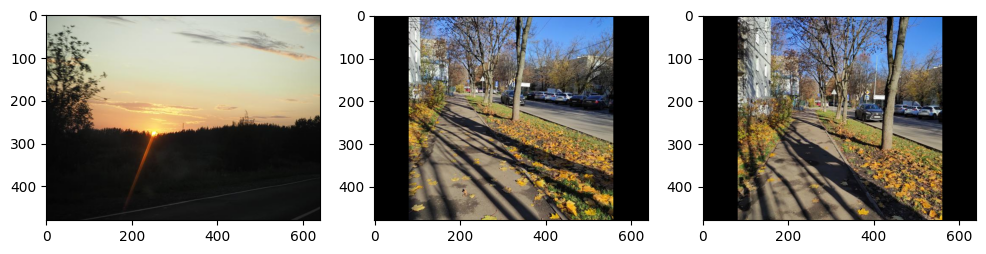

In [331]:
fig, ax = plt.subplots(figsize=(12,6), nrows=1, ncols=3)
ax[0].imshow(img0)
ax[1].imshow(img1.rotate(-90))
ax[2].imshow(img2.rotate(-90))

In [351]:
img1.size

(640, 478)

In [354]:
img0_r, img2_r = prepare_images(img0, img2)

Преобразования, чтобы привести изображения к одинаковому размеру и ориентации (по возможности)

In [387]:
def prepare_images(img1, img2):
    i = int(img1.size[0] / img1.size[1])
    j = int(img2.size[0] / img2.size[1])
    if i != j:
        img2 = img2.rotate(90)
    if (img1.size[0] == img2.size[0]) and (img1.size[1] == img2.size[1]):
        return img_as_float(img1), img_as_float(img2)
    s0 = min(img1.size[0], img2.size[0])
    s1 = min(img1.size[1], img2.size[1])
    return img_as_float(img1.resize((s0, s1))), img_as_float(img2.resize((s0, s1)))

In [388]:
img1_prepr, img2_prepr = prepare_images(img1, img2)
img0_prepr, img2_prepr = prepare_images(img0, img2)

Для похожих изображений

In [391]:
ssim_examp1 = SSIM(img1_prepr, img2_prepr, data_range=1.0, channel_axis=2)

In [392]:
ssim_examp1

0.09447128240326974

Для непохожих изображений

In [393]:
ssim_examp2 = SSIM(img0_prepr, img2_prepr, data_range=1.0, channel_axis=2)

In [394]:
ssim_examp2

0.1083928565393553

In [395]:
ssim_examp3 = SSIM(img0_prepr, img1_prepr, data_range=1.0, channel_axis=2)

In [396]:
ssim_examp3

0.10428185406003643

### Распределения для внутренних и внешних пар

In [397]:
def get_path_pairs(val_data, id_col):
    return list(zip(val_data[id_col].values, val_data['image_path'].values))

In [401]:
train_path_pairs = get_path_pairs(val_data_transf_train, 'cluster_id')

In [405]:
pair_ssim_inside = []
pair_ssim_outside = []
for i, p1 in tqdm(enumerate(train_path_pairs)):
    for p2 in train_path_pairs[i + 1:]:
        img1 = Image.open(p1[1]).convert('RGB')
        img2 = Image.open(p2[1]).convert('RGB')
        im_prep1, im_prep2 = prepare_images(img1, img2)
        pair_ssim = SSIM(im_prep1, im_prep2, data_range=1.0, channel_axis=2)
        if p1[0] == p2[0]:
            pair_ssim_inside.append(pair_ssim)
        else:
            pair_ssim_outside.append(pair_ssim)

98it [05:39,  3.47s/it]


**Для большого количества картинок это будет работать ОЧЕНЬ долго...**

<AxesSubplot: ylabel='Count'>

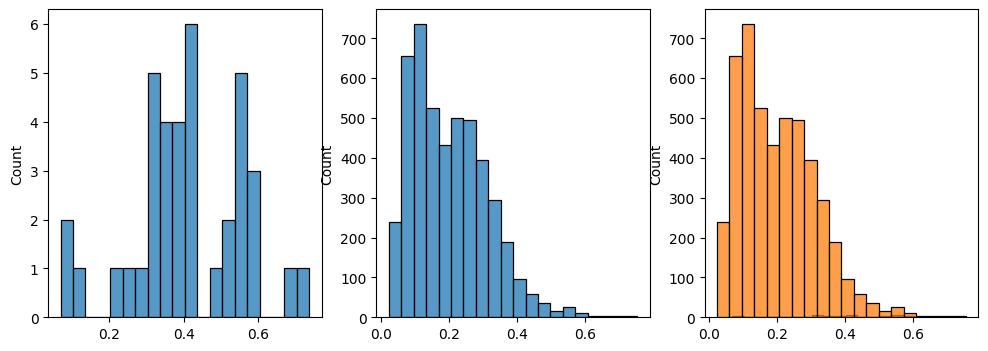

In [409]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.subplot(1, 3, 1)
sns.histplot(pair_ssim_inside, bins=20)
plt.subplot(1, 3, 2)
sns.histplot([d for d in pair_ssim_outside if d < 10], bins=20)
plt.subplot(1, 3, 3)
sns.histplot(pair_ssim_inside, bins=20)
sns.histplot([d for d in pair_ssim_outside if d < 10], bins=20)

**Не слишком многообещающе...**

## ImageHash

In [426]:
hash0 = imagehash.colorhash(img0)
hash1 = imagehash.colorhash(img1)
hash2 = imagehash.colorhash(img2)

### Сравним хэш для похожих и непохожих изображений

**Для похожих**

In [427]:
print(hash1 - hash2)

4


**Для непохожих**

In [429]:
print(hash1 - hash0)

0


In [430]:
print(hash2 - hash0)

4


### Распределения "внутренних" и "внешних" дистанций

In [433]:
pair_chash_inside = []
pair_chash_outside = []
for i, p1 in tqdm(enumerate(train_path_pairs)):
    for p2 in train_path_pairs[i + 1:]:
        img1 = Image.open(p1[1]).convert('RGB')
        img2 = Image.open(p2[1]).convert('RGB')
        d = imagehash.colorhash(img1) - imagehash.colorhash(img2)
        if p1[0] == p2[0]:
            pair_chash_inside.append(d)
        else:
            pair_chash_outside.append(d)

98it [02:01,  1.24s/it]


<AxesSubplot: ylabel='Count'>

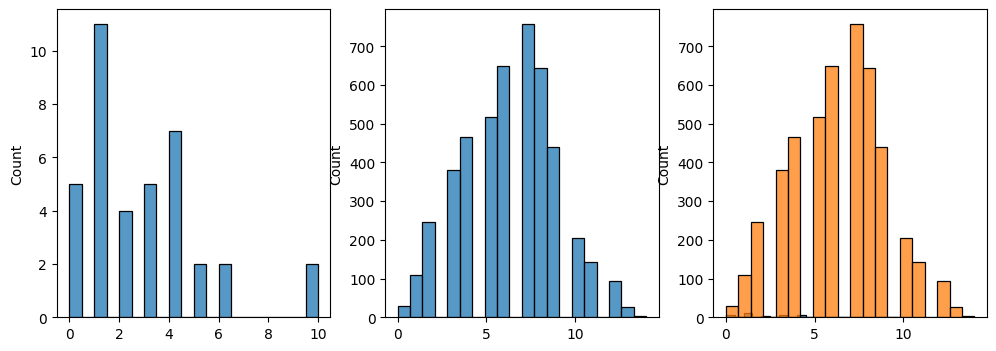

In [434]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
plt.subplot(1, 3, 1)
sns.histplot(pair_chash_inside, bins=20)
plt.subplot(1, 3, 2)
sns.histplot(pair_chash_outside, bins=20)
plt.subplot(1, 3, 3)
sns.histplot(pair_chash_inside, bins=20)
sns.histplot(pair_chash_outside, bins=20)

Также не выглядит перспективно

## Выводы

+ лучшие эмбеддинги кластеризации - эмбеддинги трансформера. Метрики, полученные с этими эмбеддингами методом плотностной кластеризации:
    ARI: 0.51,
    AMI: 0.66,
    completeness: 0.82,
    homogeneity: 0.82

    методом кластеризации графа:
    ARI: 0.56,
    AMI: 0.69,
    completeness: 0.85,
    homogeneity: 0.84


+ наивысшие показания по метрикам дает построение графа с его последующей кластеризацией. Недостатки такого способа: для реализации такого варианта нужна хотя бы небольшая "обучающая" выборка - оценить распределения попарных расстояний между элементами одного кластера и разных кластеров; более трудоемкий способ. Графовый метод, веротяно, больше подходит для задач, где больше данных, и где есть несколько признаков группировки (чтобы использовать все признаки).

+ плотностная кластеризация дает результаты ненамного ниже и не требует обучающей выборки.